# S1.1 — Annual and climatological products / 年度与气候态产品

S1 downloads monthly files. This notebook does **not** query ESGF. It converts each model's native-grid monthly raw output into comparable **1985–2014** annual climatologies, using **calendar-aware** temporal aggregation.

**中文说明：** S1只负责下载。S1.1按各模式自己的日历做时间聚合，保留原网格，校验单位后再换算。不假定公历，也不写死所有通量都是 kg m⁻² s⁻¹。

S1.1 converts each model’s monthly raw outputs into comparable 1985–2014 annual climatologies, using calendar-aware temporal aggregation and retaining model-native spatial grids.


## 1. Configuration / 配置

`PROCESS_MODELS = ['CanESM5']` for a smoke test; `None` processes every ready model without leftover `.part` files.

Fluxes (`flux_total`) are integrated after **unit validation**. States (`state_mean`) keep their original units (`tas` is usually K). `sftgif` is optional.

**中文说明：** 先试CanESM5。水通量先看units再积分；状态量保留原单位。


In [13]:
from __future__ import annotations

import gc
import json
import sys
import time
import traceback
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr


def locate_case_dir() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / 'cmip_utils.py').exists() and candidate.name == 'caseA':
            return candidate
        nested = candidate / 'case' / 'caseA'
        if (nested / 'cmip_utils.py').exists():
            return nested
    raise FileNotFoundError('Could not locate case/caseA/cmip_utils.py')


CASE_DIR = locate_case_dir()
if str(CASE_DIR) not in sys.path:
    sys.path.insert(0, str(CASE_DIR))

from cmip_utils import (
    harmonize_horizontal_grid,
    monthly_flux_to_annual_total,
    monthly_state_to_annual_mean,
    normalize_fraction_to_percent,
    normalize_longitude,
    open_time_series,
    processing_signature,
)

DATA_ROOT = Path('/Volumes/mimi-T9/CMIP6')
PLAN_PATH = DATA_ROOT / 'S1_run_plan.csv'

# None = all ready models with complete raw files.
# Smoke test: PROCESS_MODELS = ['CanESM5']
PROCESS_MODELS = None

EXPERIMENT_ID = 'historical'
START_YEAR = 1985
END_YEAR = 2014
SPATIAL_EXTENT = 'global'
PROCESSING_VERSION = 'S1.1-annual-climatology-v4-snw'

TIME_VARIABLES = {
    'P':           {'variable_id': 'pr',         'processing': 'flux_total'},
    'ET':          {'variable_id': 'evspsbl',    'processing': 'flux_total'},
    'R':           {'variable_id': 'mrro',       'processing': 'flux_total'},
    'tas':         {'variable_id': 'tas',        'processing': 'state_mean'},
    'rsds':        {'variable_id': 'rsds',       'processing': 'state_mean'},
    'rsus':        {'variable_id': 'rsus',       'processing': 'state_mean'},
    'rlds':        {'variable_id': 'rlds',       'processing': 'state_mean'},
    'rlus':        {'variable_id': 'rlus',       'processing': 'state_mean'},
    'hfls':        {'variable_id': 'hfls',       'processing': 'state_mean'},
    'hfss':        {'variable_id': 'hfss',       'processing': 'state_mean'},
    'mrso':        {'variable_id': 'mrso',       'processing': 'state_mean'},
    'lai':         {'variable_id': 'lai',        'processing': 'state_mean'},
    'mrsos':       {'variable_id': 'mrsos',      'processing': 'state_mean'},
    'mrros':       {'variable_id': 'mrros',      'processing': 'flux_total'},
    'prsn':        {'variable_id': 'prsn',       'processing': 'flux_total'},
    'snw':         {'variable_id': 'snw',        'processing': 'state_mean'},
    'evspsblsoi':  {'variable_id': 'evspsblsoi', 'processing': 'flux_total'},
    'tran':        {'variable_id': 'tran',       'processing': 'flux_total'},
}

FIXED_FIELDS = {
    'cell_area':         {'variable_id': 'areacella', 'required': True},
    'land_fraction':     {'variable_id': 'sftlf',     'required': True},
    'land_ice_fraction': {'variable_id': 'sftgif',    'required': False},
}

print(f'Case directory: {CASE_DIR}')
print(f'Data root: {DATA_ROOT} (exists={DATA_ROOT.exists()})')
print(f'Time variables: {list(TIME_VARIABLES)}')


Case directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA
Data root: /Volumes/mimi-T9/CMIP6 (exists=True)
Time variables: ['P', 'ET', 'R', 'tas', 'rsds', 'rsus', 'rlds', 'rlus', 'hfls', 'hfss', 'mrso', 'lai', 'mrsos', 'mrros', 'prsn', 'evspsblsoi', 'tran']


## 2. Discover local raw files / 扫描本地raw文件

No ESGF. Skip a model if the plan is not `ready`, `raw/` is missing, or `.part` files remain. P, R, areacella and sftlf are required; core-pool models also need ET.

**中文说明：** 只扫硬盘。缺必需场或还在下载则跳过。


In [14]:
def _merge_and_save(new_df: pd.DataFrame, path: Path, key_cols: list[str]) -> pd.DataFrame:
    if path.exists():
        existing = pd.read_csv(path)
        existing = existing[~existing.set_index(key_cols).index.isin(new_df.set_index(key_cols).index)]
        merged = pd.concat([existing, new_df], ignore_index=True)
    else:
        merged = new_df
    merged.to_csv(path, index=False)
    return merged


def list_nc(raw_root: Path, variable_id: str) -> list[Path]:
    folder = raw_root / variable_id
    if not folder.is_dir():
        return []
    return sorted(p for p in folder.glob('*.nc') if p.is_file() and p.stat().st_size > 0)


plan = pd.read_csv(PLAN_PATH)
if PROCESS_MODELS is not None:
    plan = plan[plan['model'].isin(PROCESS_MODELS)].copy()

RUNS = []
skip_rows = []

for _, row in plan.iterrows():
    model = row['model']
    member = row['member']
    grid = str(row['grid']).split(',')[0].strip()
    pool = row.get('pool', 'core')
    run_root = DATA_ROOT / model / EXPERIMENT_ID / member / grid
    raw_root = run_root / 'raw'
    parts = list(raw_root.rglob('*.part')) if raw_root.exists() else []

    time_paths = {}
    for alias, spec in TIME_VARIABLES.items():
        paths = list_nc(raw_root, spec['variable_id']) if raw_root.exists() else []
        if paths:
            time_paths[alias] = paths

    fixed_paths = {}
    for alias, spec in FIXED_FIELDS.items():
        paths = list_nc(raw_root, spec['variable_id']) if raw_root.exists() else []
        fixed_paths[alias] = paths[0] if paths else None

    reasons = []
    if str(row.get('status', '')) != 'ready':
        reasons.append(f"plan status={row.get('status')}")
    if not raw_root.exists():
        reasons.append('no raw directory')
    if parts:
        reasons.append(f'{len(parts)} .part file(s) still present')
    if 'P' not in time_paths:
        reasons.append('missing pr')
    if 'R' not in time_paths:
        reasons.append('missing mrro')
    if pool == 'core' and 'ET' not in time_paths:
        reasons.append('missing evspsbl')
    if fixed_paths['cell_area'] is None:
        reasons.append('missing areacella')
    if fixed_paths['land_fraction'] is None:
        reasons.append('missing sftlf')

    rec = {
        'model': model,
        'family': row.get('family', ''),
        'pool': pool,
        'member_id': member,
        'grid_label': grid,
        'run_root': run_root,
        'time_paths': time_paths,
        'fixed_paths': fixed_paths,
        'n_time_vars': len(time_paths),
        'n_time_files': sum(len(v) for v in time_paths.values()),
        'has_sftgif': fixed_paths['land_ice_fraction'] is not None,
        'status': 'processable' if not reasons else 'skip',
        'skip_reason': '; '.join(reasons),
    }
    if reasons:
        skip_rows.append(rec)
        print(f'{model}: SKIP — {rec["skip_reason"]}')
    else:
        RUNS.append(rec)
        print(
            f'{model}: {len(time_paths)} time vars, '
            f'{rec["n_time_files"]} nc, sftgif={"yes" if rec["has_sftgif"] else "no"}'
        )

SCAN = pd.DataFrame(
    [{k: r[k] for k in ('model', 'family', 'member_id', 'grid_label', 'n_time_vars', 'n_time_files', 'has_sftgif', 'status', 'skip_reason')}
     for r in RUNS + skip_rows]
)
print(f'\nProcessable: {len(RUNS)} / {len(plan)}')
print(SCAN.to_string(index=False))


CESM2: 17 time vars, 17 nc, sftgif=yes
CNRM-CM6-1: 17 time vars, 17 nc, sftgif=yes
CanESM5: 17 time vars, 17 nc, sftgif=yes
E3SM-1-0: 17 time vars, 34 nc, sftgif=no
GFDL-CM4: 17 time vars, 17 nc, sftgif=yes
IPSL-CM6A-LR: 17 time vars, 17 nc, sftgif=no
MIROC-ES2H: 17 time vars, 17 nc, sftgif=yes
MRI-ESM2-0: SKIP — missing pr; missing evspsbl
CMCC-CM2-SR5: 17 time vars, 17 nc, sftgif=yes
FGOALS-g3: 17 time vars, 61 nc, sftgif=no
NorESM2-LM: 13 time vars, 52 nc, sftgif=yes

Processable: 10 / 11
       model    family member_id grid_label  n_time_vars  n_time_files  has_sftgif      status                 skip_reason
       CESM2     CESM2  r1i1p1f1         gn           17            17        True processable                            
  CNRM-CM6-1      CNRM  r1i1p1f2         gr           17            17        True processable                            
     CanESM5    CanESM  r1i1p1f1         gn           17            17        True processable                            
    E3SM-1-

## 3. Build annual and climatology / 构建年度与气候态

1. Validate units, CF calendar, and 360-month completeness.
2. Fluxes: if `kg m⁻² s⁻¹` (or mm/day / monthly mm), integrate with **calendar-aware** `days_in_month` → mm yr⁻¹. Do not assume Gregorian months.
3. States/intensities: day-weighted annual mean, **original units retained**.
4. Check horizontal grid vs P (shape + lat/lon). Mismatch → **drop that optional variable** and continue. Required P/R/area/sftlf mismatch still fails the model. No regridding.
5. Attach area / land / ice. `WB_res = P − ET − R` is a **QC storage residual**, not a closed water-balance error.
6. Equal-weight mean of the 30 annual maps.

**中文说明：** 日历来自时间轴；单位先校验；网格不一致就丢掉该可选变量，不整模直接死；WB只作残差检查。


In [11]:
def _atomic_netcdf(dataset: xr.Dataset, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + '.tmp')
    dataset.to_netcdf(temporary)
    temporary.replace(path)


def _atomic_parquet(frame: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + '.tmp')
    frame.to_parquet(temporary, index=False)
    temporary.replace(path)


def _load_fixed(path: Path, variable_id: str) -> xr.DataArray:
    with xr.open_dataset(path) as dataset:
        if variable_id not in dataset:
            raise KeyError(f'{variable_id!r} absent from {path}')
        return normalize_longitude(dataset[variable_id].load())


def _file_stamp(path: Path) -> dict:
    return {'name': path.name, 'size': path.stat().st_size}



GRID_ATOL = 1e-4  # degrees; Amon vs Lmon often differ by ~1e-6


def _grid_mismatch(reference, array) -> str | None:
    """Return None if lat/lon match the reference; else an error string."""
    try:
        harmonize_horizontal_grid(
            {'ref': reference, 'other': array},
            reference_name='ref',
            atol=GRID_ATOL,
        )
    except ValueError as exc:
        return str(exc)
    return None


def _signature_payload(run: dict) -> dict:
    return {
        'processing_version': PROCESSING_VERSION,
        'model': run['model'],
        'experiment': EXPERIMENT_ID,
        'member': run['member_id'],
        'grid': run['grid_label'],
        'period': [START_YEAR, END_YEAR],
        'time_files': {
            alias: [_file_stamp(p) for p in paths]
            for alias, paths in run['time_paths'].items()
        },
        'fixed_files': {
            alias: None if path is None else _file_stamp(path)
            for alias, path in run['fixed_paths'].items()
        },
    }


def process_run(run: dict) -> tuple[int, str]:
    processed_dir = run['run_root'] / 'processed'
    processed_dir.mkdir(parents=True, exist_ok=True)
    annual_path = processed_dir / f'global_annual_{START_YEAR}_{END_YEAR}.nc'
    climatology_path = processed_dir / f'global_climatology_{START_YEAR}_{END_YEAR}.nc'
    parquet_path = processed_dir / f'global_climatology_{START_YEAR}_{END_YEAR}.parquet'
    signature_path = processed_dir / f'global_processing_{START_YEAR}_{END_YEAR}.json'
    signature = processing_signature(_signature_payload(run))

    if all(p.exists() for p in [annual_path, climatology_path, parquet_path, signature_path]):
        try:
            if json.loads(signature_path.read_text())['signature'] == signature:
                fixed_and_derived = {
                    'cell_area', 'land_fraction', 'land_ice_fraction',
                    'land_area', 'land_ice_area', 'non_ice_land_area', 'WB',
                }
                with xr.open_dataset(annual_path) as ds:
                    n_vars = len([v for v in ds.data_vars if v not in fixed_and_derived])
                return n_vars, 'existing-processed'
        except Exception:
            pass

    annual_arrays = {}
    for alias, spec in TIME_VARIABLES.items():
        paths = run['time_paths'].get(alias)
        if not paths:
            continue
        monthly = open_time_series(
            paths, spec['variable_id'], start_year=START_YEAR, end_year=END_YEAR
        )
        monthly = normalize_longitude(monthly)
        if spec['processing'] == 'flux_total':
            annual = monthly_flux_to_annual_total(monthly)
        elif spec['processing'] == 'state_mean':
            annual = monthly_state_to_annual_mean(monthly)
        else:
            raise ValueError(f"Unknown processing rule: {spec['processing']}")
        annual.name = alias
        annual_arrays[alias] = annual
        del monthly

    if 'P' not in annual_arrays:
        raise ValueError('P is required')
    if 'R' not in annual_arrays:
        raise ValueError('R is required')

    dropped = []
    kept = {'P': annual_arrays['P']}
    required_time = {'P', 'R'}
    if run['pool'] == 'core':
        required_time.add('ET')

    for alias, annual in annual_arrays.items():
        if alias == 'P':
            continue
        mismatch = _grid_mismatch(annual_arrays['P'], annual)
        if mismatch is None:
            kept[alias] = annual
            continue
        if alias in required_time:
            raise ValueError(f'required field {alias} is not on the P grid: {mismatch}')
        dropped.append(f'{alias}: {mismatch}')
        print(f'  drop {alias} (grid mismatch vs P)')

    annual_arrays = harmonize_horizontal_grid(kept, reference_name='P', atol=GRID_ATOL)
    expected_years = np.arange(START_YEAR, END_YEAR + 1)
    for alias, annual in annual_arrays.items():
        if not np.array_equal(annual['year'].values, expected_years):
            raise ValueError(f'{alias} does not contain every requested year')
    annual_ds = xr.Dataset(annual_arrays)
    run['dropped_variables'] = dropped

    fixed_arrays = {}
    for alias, spec in FIXED_FIELDS.items():
        path = run['fixed_paths'].get(alias)
        if path is None:
            continue
        loaded = _load_fixed(path, spec['variable_id'])
        mismatch = _grid_mismatch(annual_arrays['P'], loaded)
        if mismatch is None:
            fixed_arrays[alias] = loaded
            continue
        if spec.get('required', False):
            raise ValueError(f'required fixed field {alias} is not on the P grid: {mismatch}')
        dropped.append(f'{alias}: {mismatch}')
        print(f'  drop {alias} (grid mismatch vs P)')
        run['fixed_paths'][alias] = None

    if 'cell_area' not in fixed_arrays or 'land_fraction' not in fixed_arrays:
        raise ValueError('cell_area and land_fraction are required')
    fixed_arrays['land_fraction'] = normalize_fraction_to_percent(
        fixed_arrays['land_fraction'], name='sftlf'
    )
    if 'land_ice_fraction' in fixed_arrays:
        fixed_arrays['land_ice_fraction'] = normalize_fraction_to_percent(
            fixed_arrays['land_ice_fraction'], name='sftgif'
        )

    ref_and_fixed = {'P': annual_arrays['P'], **fixed_arrays}
    harmonized = harmonize_horizontal_grid(ref_and_fixed, reference_name='P', atol=GRID_ATOL)
    fixed_arrays = {a: harmonized[a] for a in fixed_arrays}
    del ref_and_fixed, harmonized

    cell_area = fixed_arrays['cell_area'].astype('float64')
    area_units = str(cell_area.attrs.get('units', '')).lower().replace(' ', '').replace('**', '^')
    if area_units not in {'m2', 'm^2'}:
        raise ValueError(f"Expected areacella in m2, found units={cell_area.attrs.get('units')!r}")
    if float(cell_area.min(skipna=True)) <= 0:
        raise ValueError('areacella must be positive')

    land_fraction = fixed_arrays['land_fraction']
    land_area = cell_area * land_fraction / 100.0
    land_area.attrs = {'long_name': 'land-covered grid-cell area', 'units': 'm2'}

    if 'land_ice_fraction' in fixed_arrays:
        land_ice_fraction = fixed_arrays['land_ice_fraction']
        overlap = np.isfinite(land_fraction) & np.isfinite(land_ice_fraction)
        excess = (land_ice_fraction > land_fraction + 1e-5) & overlap
        if bool(excess.any()):
            n_ex = int(excess.sum())
            print(f'  clip sftgif to sftlf on {n_ex} cells (ice fraction > land fraction)')
            land_ice_fraction = xr.where(excess, land_fraction, land_ice_fraction)
            land_ice_fraction.attrs = dict(fixed_arrays['land_ice_fraction'].attrs)
            land_ice_fraction.attrs['processing'] = 'clipped so sftgif <= sftlf'
        land_ice_area = cell_area * land_ice_fraction / 100.0
        non_ice_land_area = cell_area * (land_fraction - land_ice_fraction).clip(0.0, 100.0) / 100.0
        land_ice_area.attrs = {'long_name': 'land-ice-covered grid-cell area', 'units': 'm2'}
        non_ice_land_area.attrs = {'long_name': 'non-ice land grid-cell area', 'units': 'm2'}
        land_ice_status = 'available'
    else:
        land_ice_fraction = xr.full_like(land_fraction, np.nan)
        land_ice_fraction.attrs = {
            'long_name': 'land ice area percentage', 'units': '%', 'availability': 'unavailable',
        }
        land_ice_area = xr.full_like(cell_area, np.nan)
        non_ice_land_area = xr.full_like(cell_area, np.nan)
        land_ice_status = 'unavailable'

    annual_ds['cell_area'] = cell_area
    annual_ds['land_fraction'] = land_fraction
    annual_ds['land_ice_fraction'] = land_ice_fraction
    annual_ds['land_area'] = land_area
    annual_ds['land_ice_area'] = land_ice_area
    annual_ds['non_ice_land_area'] = non_ice_land_area

    if {'P', 'ET', 'R'} <= set(annual_ds.data_vars):
        annual_ds['WB'] = annual_ds['P'] - annual_ds['ET'] - annual_ds['R']
        annual_ds['WB'].attrs = {
            'long_name': 'water-balance residual / long-term storage residual P-ET-R',
            'units': 'mm yr-1',
            'note': 'QC diagnostic only. P-ET-R equals storage change (soil, snow, groundwater); not a closed land budget.',
        }

    n_time_vars = len(annual_arrays)
    time_var_names = list(annual_arrays.keys())
    climatology_ds = annual_ds[time_var_names].mean('year', keep_attrs=True)
    for name in ('cell_area', 'land_fraction', 'land_ice_fraction', 'land_area', 'land_ice_area', 'non_ice_land_area'):
        climatology_ds[name] = annual_ds[name]
    if 'WB' in annual_ds:
        climatology_ds['WB'] = climatology_ds['P'] - climatology_ds['ET'] - climatology_ds['R']
        climatology_ds['WB'].attrs = {
            'long_name': 'water-balance residual / long-term storage residual P-ET-R',
            'units': 'mm yr-1',
            'note': 'QC diagnostic only. P-ET-R equals storage change (soil, snow, groundwater); not a closed land budget.',
        }

    common_attrs = {
        'source_id': run['model'],
        'experiment_id': EXPERIMENT_ID,
        'member_id': run['member_id'],
        'grid_label': run['grid_label'],
        'spatial_extent': SPATIAL_EXTENT,
        'analysis_period': f'{START_YEAR}-{END_YEAR}',
        'land_ice_status': land_ice_status,
        'processing_version': PROCESSING_VERSION,
        'pool': run['pool'],
        'evspsbl_sign_policy': 'original CMIP6 sign preserved',
    }
    annual_ds.attrs.update(common_attrs)
    climatology_ds.attrs.update(common_attrs)

    _atomic_netcdf(annual_ds, annual_path)
    _atomic_netcdf(climatology_ds, climatology_path)

    table = climatology_ds.to_dataframe().reset_index()
    table.insert(0, 'model', run['model'])
    table.insert(1, 'experiment', EXPERIMENT_ID)
    table.insert(2, 'member', run['member_id'])
    table.insert(3, 'grid', run['grid_label'])
    table.insert(4, 'period_start', START_YEAR)
    table.insert(5, 'period_end', END_YEAR)
    _atomic_parquet(table, parquet_path)

    signature_path.write_text(
        json.dumps({'signature': signature, 'payload': _signature_payload(run)}, indent=2),
        encoding='utf-8',
    )

    del annual_ds, climatology_ds, annual_arrays, fixed_arrays, table
    gc.collect()
    return n_time_vars, 'processed-now'


if not RUNS:
    print('Nothing to process. Finish S1 downloads first (no .part files).')
else:
    process_t0 = time.time()
    PROCESSED = []
    FAILED_PROCESSING = []
    for i, run in enumerate(RUNS):
        model = run['model']
        print(f'[{i+1}/{len(RUNS)}] Processing {model}...')
        t0 = time.time()
        try:
            n_vars, status = process_run(run)
            run['processed_status'] = status
            PROCESSED.append(run)
            dropped = run.get('dropped_variables') or []
            extra = f'; dropped {dropped}' if dropped else ''
            print(f'  {model}: {status} ({n_vars} vars, {time.time()-t0:.0f}s){extra}')
        except Exception as exc:
            print(f'  *** FAILED after {time.time()-t0:.0f}s: {exc}')
            traceback.print_exc()
            FAILED_PROCESSING.append((model, str(exc)))
        gc.collect()

    print(f'\nProcessing complete in {time.time()-process_t0:.0f}s')
    print(f'{len(PROCESSED)} succeeded, {len(FAILED_PROCESSING)} failed')
    for model, err in FAILED_PROCESSING:
        print(f'  FAILED: {model}: {err}')


[1/10] Processing CESM2...
  CESM2: existing-processed (17 vars, 0s)
[2/10] Processing CNRM-CM6-1...
  CNRM-CM6-1: existing-processed (17 vars, 0s)
[3/10] Processing CanESM5...
  CanESM5: existing-processed (17 vars, 0s)
[4/10] Processing E3SM-1-0...
  E3SM-1-0: existing-processed (17 vars, 0s)
[5/10] Processing GFDL-CM4...
  GFDL-CM4: existing-processed (17 vars, 0s)
[6/10] Processing IPSL-CM6A-LR...
  IPSL-CM6A-LR: existing-processed (17 vars, 0s)
[7/10] Processing MIROC-ES2H...
  *** FAILED after 6s: required fixed field cell_area is not on the P grid: Latitude shape mismatch: ref (128,) vs other (64,)
[8/10] Processing CMCC-CM2-SR5...
  CMCC-CM2-SR5: existing-processed (17 vars, 0s)
[9/10] Processing FGOALS-g3...


Traceback (most recent call last):
  File "/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_52256/869479432.py", line 276, in <module>
    n_vars, status = process_run(run)
  File "/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_52256/869479432.py", line 145, in process_run
    raise ValueError(f'required fixed field {alias} is not on the P grid: {mismatch}')
ValueError: required fixed field cell_area is not on the P grid: Latitude shape mismatch: ref (128,) vs other (64,)


  FGOALS-g3: processed-now (17 vars, 3s)
[10/10] Processing NorESM2-LM...
  NorESM2-LM: processed-now (13 vars, 2s)

Processing complete in 12s
9 succeeded, 1 failed
  FAILED: MIROC-ES2H: required fixed field cell_area is not on the P grid: Latitude shape mismatch: ref (128,) vs other (64,)


## 4. QC / 质量检查

Descriptive only. Maps show P, ET, R and `WB_res` (long-term storage residual). Negative ET is counted, not flipped.

**中文说明：** 残差很大才值得查，不要把它当成完整陆面闭合误差。


CESM2 negative ET: annual values=108017, climatological cells=3593


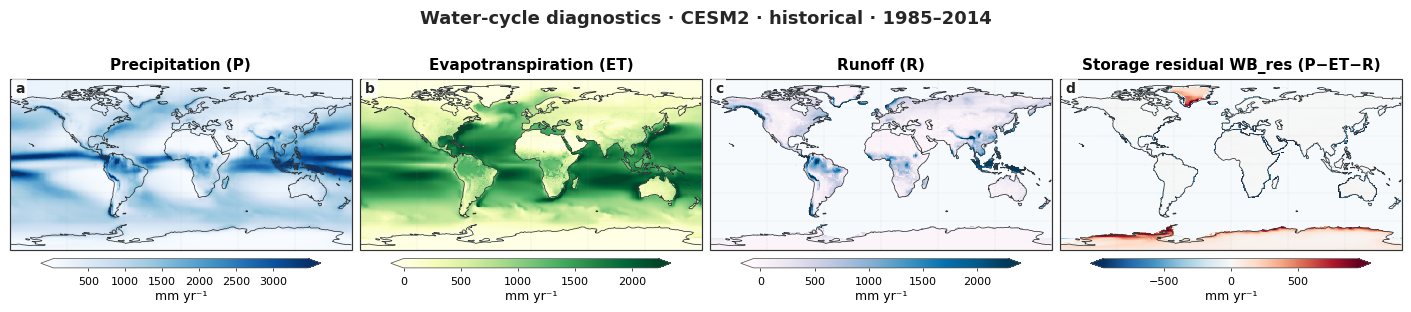

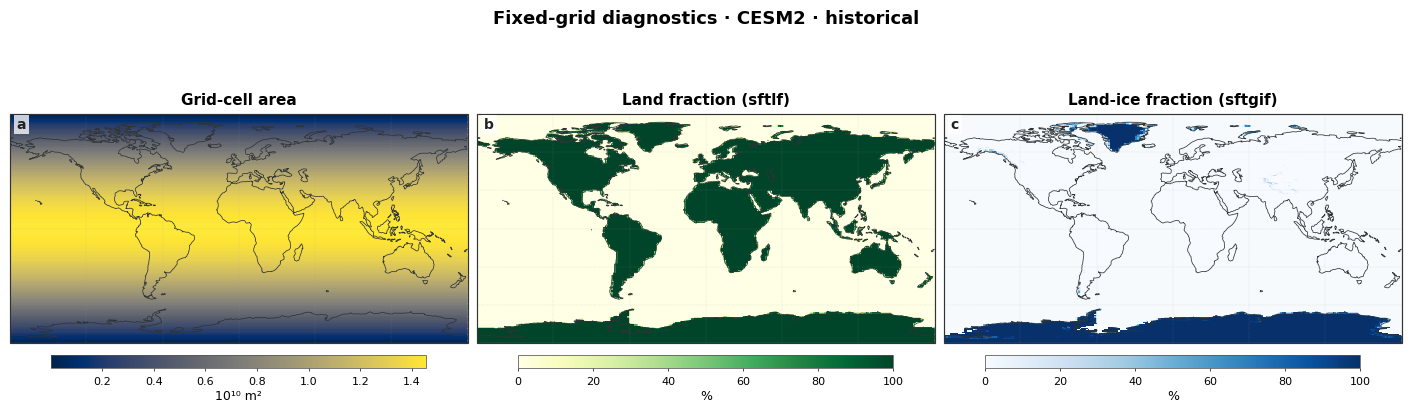

CESM2: 17 time variables in climatology
CNRM-CM6-1 negative ET: annual values=9490, climatological cells=271


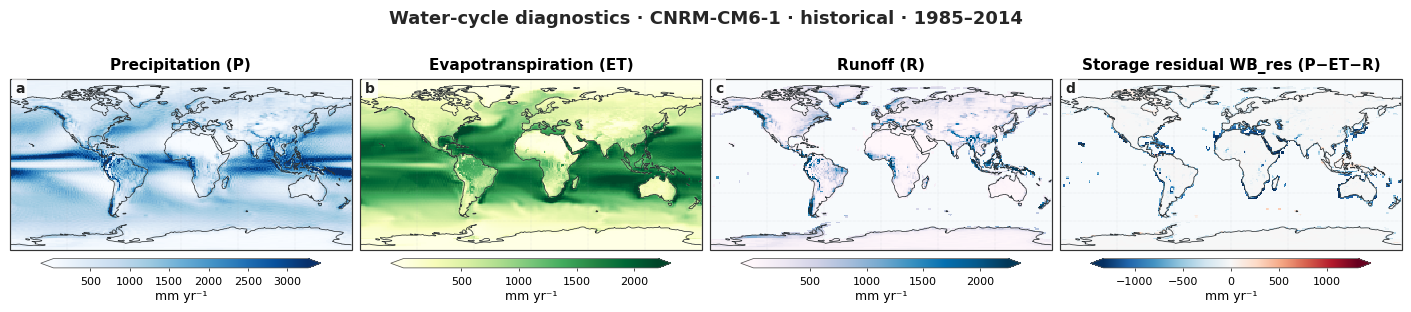

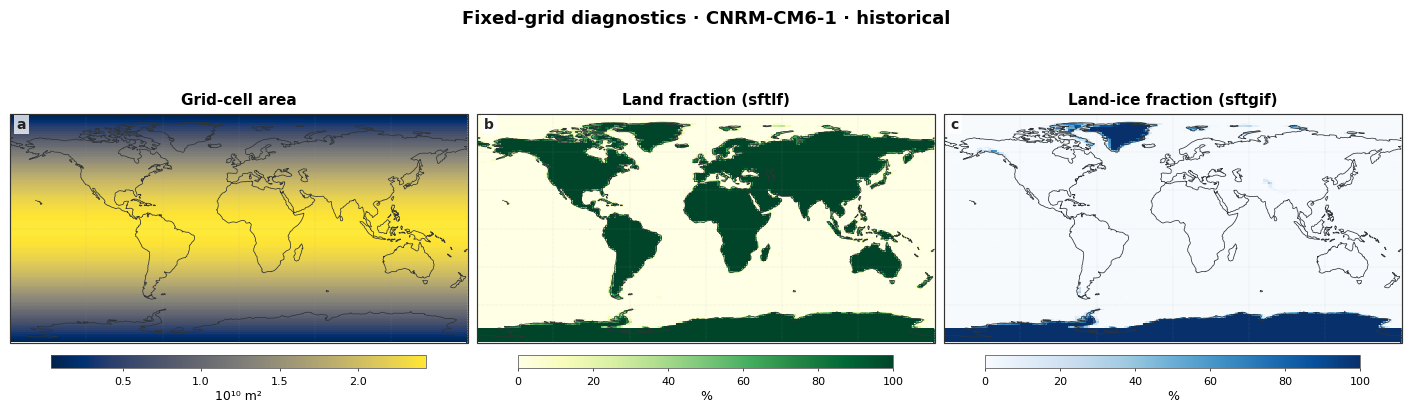

CNRM-CM6-1: 17 time variables in climatology
CanESM5 negative ET: annual values=164, climatological cells=3


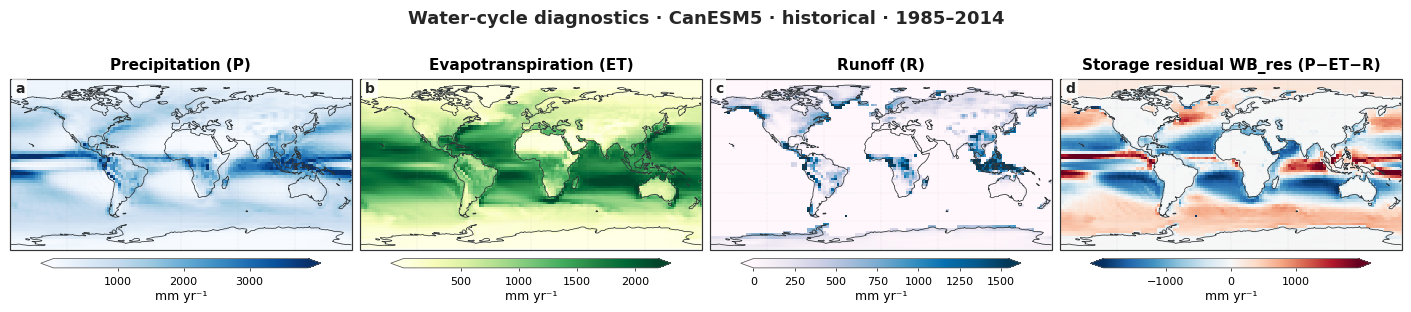

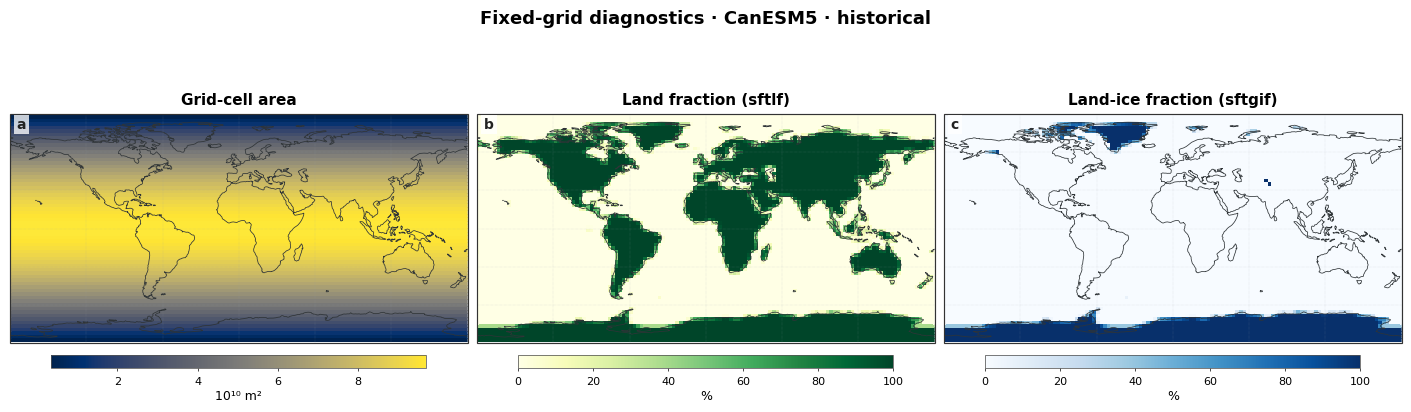

CanESM5: 17 time variables in climatology
E3SM-1-0 negative ET: annual values=49452, climatological cells=1544


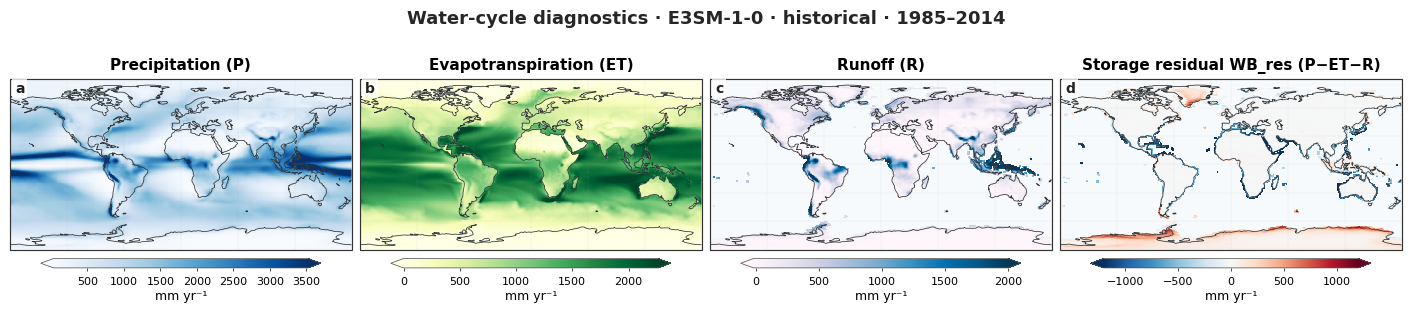

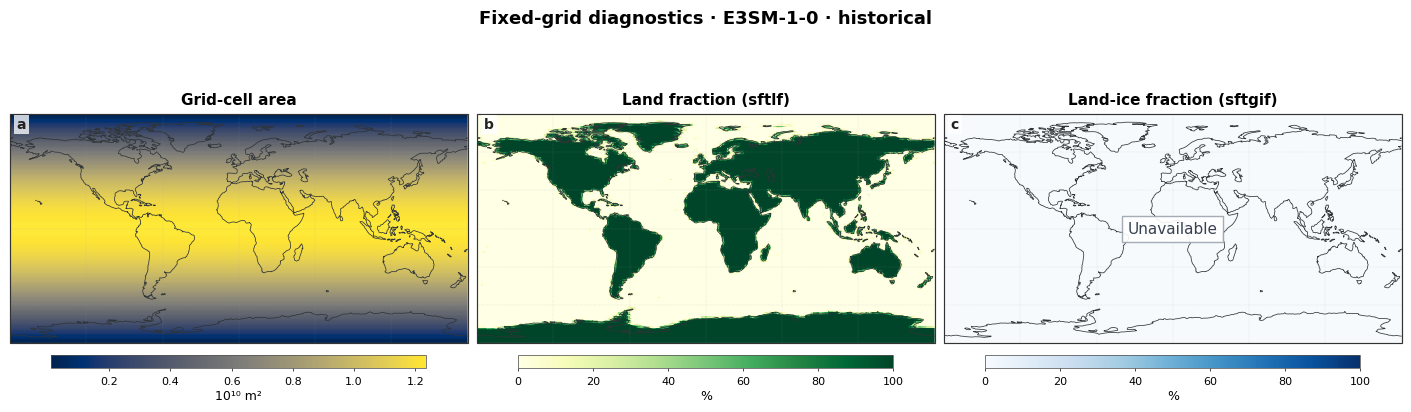

E3SM-1-0: 17 time variables in climatology
GFDL-CM4 negative ET: annual values=82659, climatological cells=2768


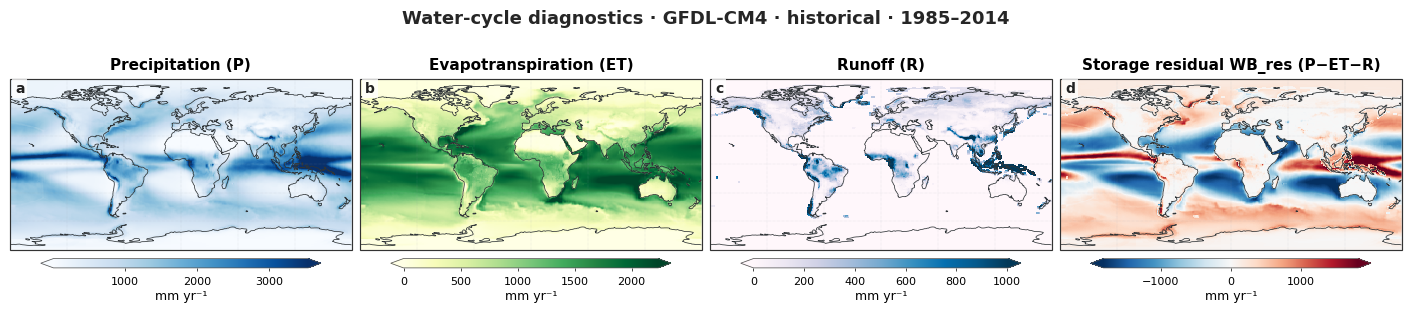

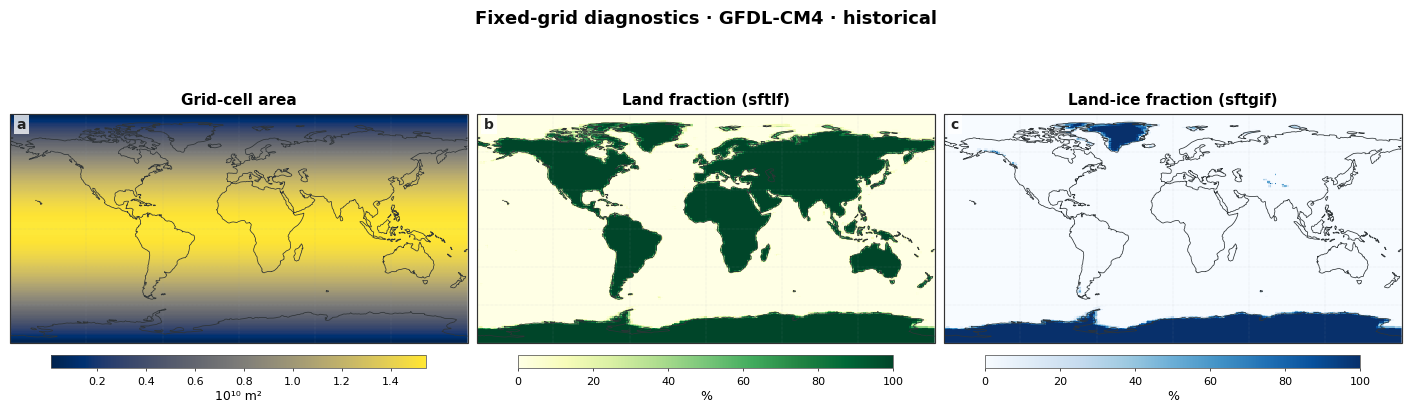

GFDL-CM4: 17 time variables in climatology
IPSL-CM6A-LR negative ET: annual values=33671, climatological cells=1122


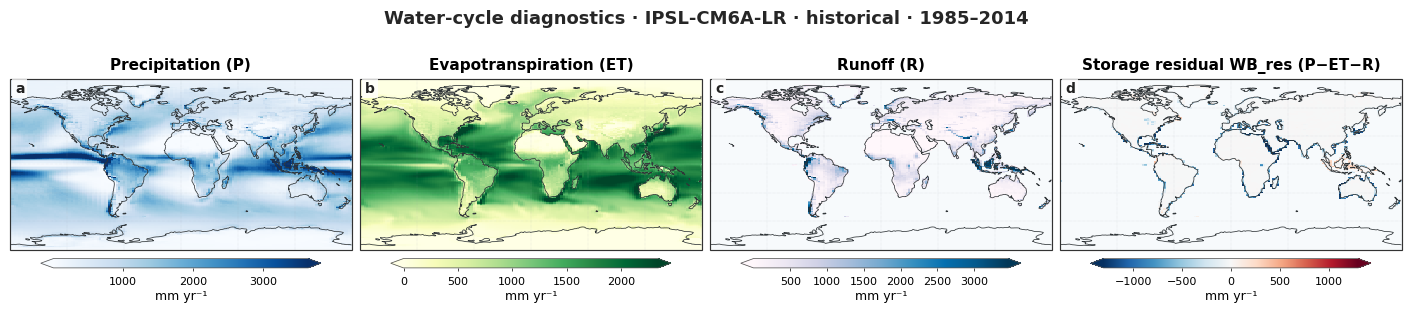

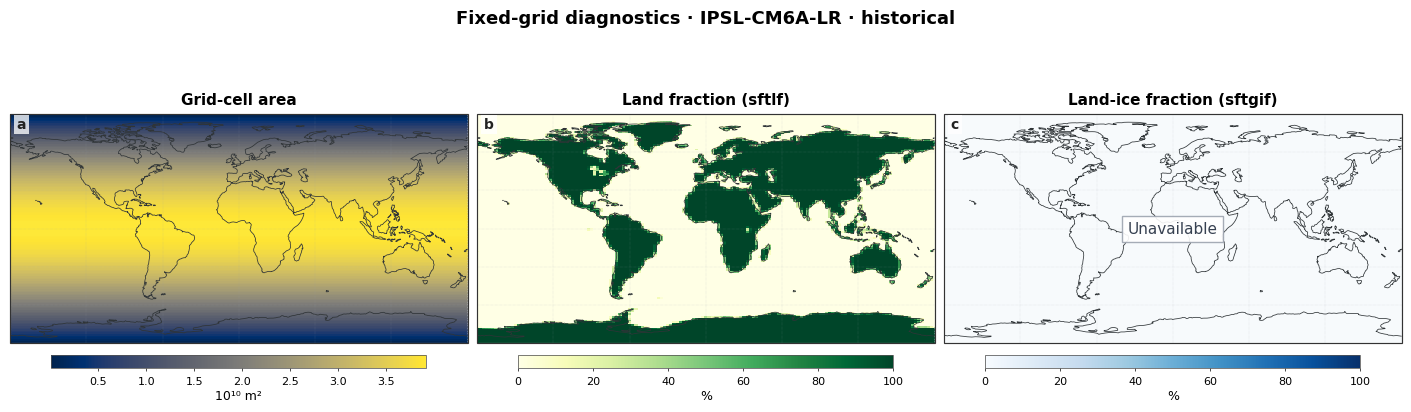

IPSL-CM6A-LR: 17 time variables in climatology
CMCC-CM2-SR5 negative ET: annual values=26632, climatological cells=888


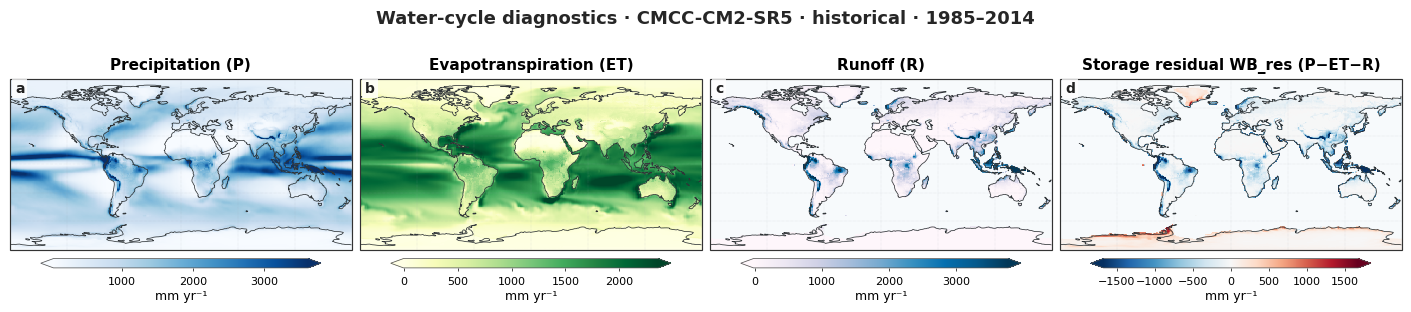

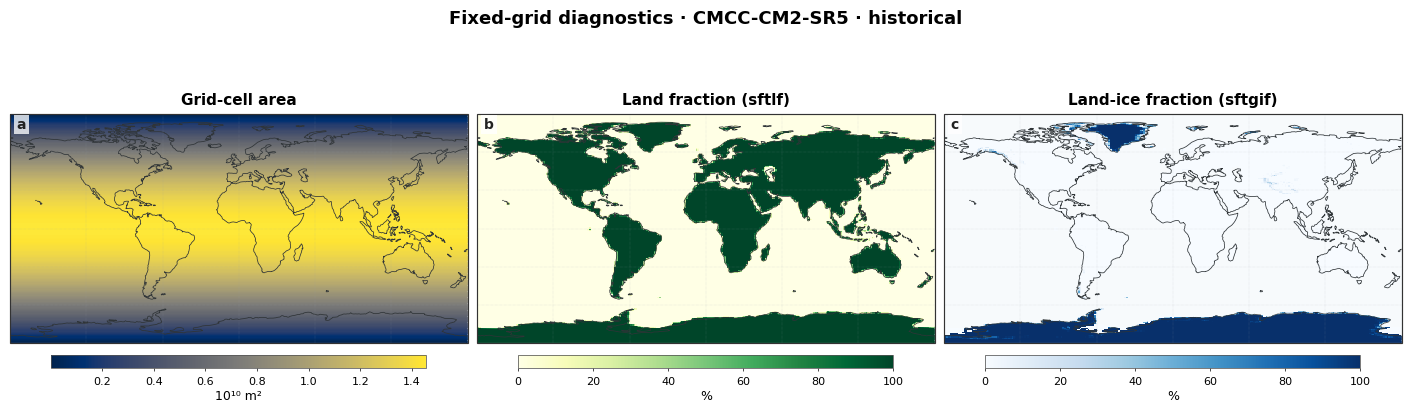

CMCC-CM2-SR5: 17 time variables in climatology
FGOALS-g3 negative ET: annual values=13736, climatological cells=455


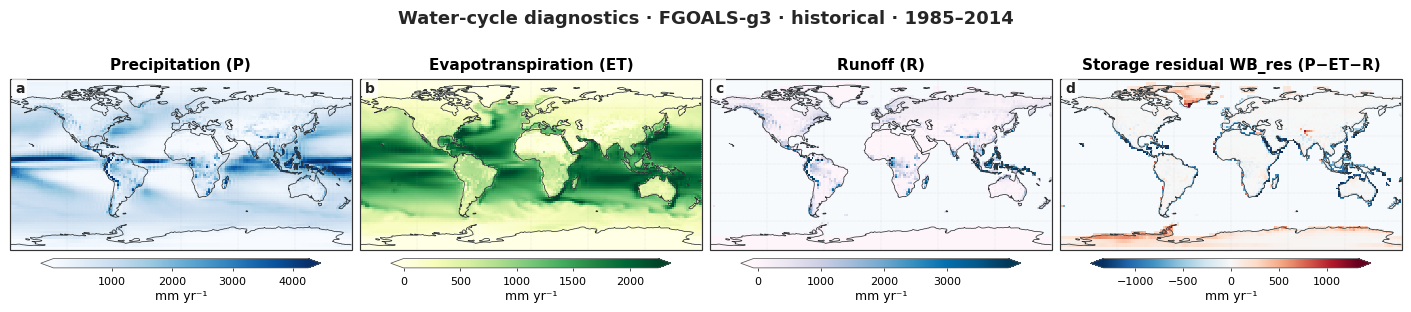

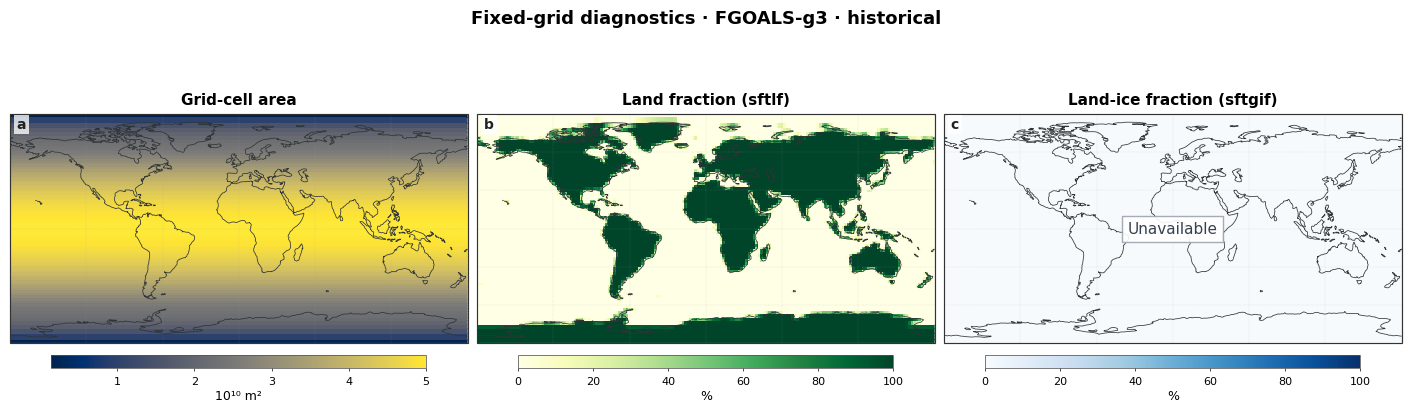

FGOALS-g3: 17 time variables in climatology
NorESM2-LM negative ET: annual values=26634, climatological cells=885


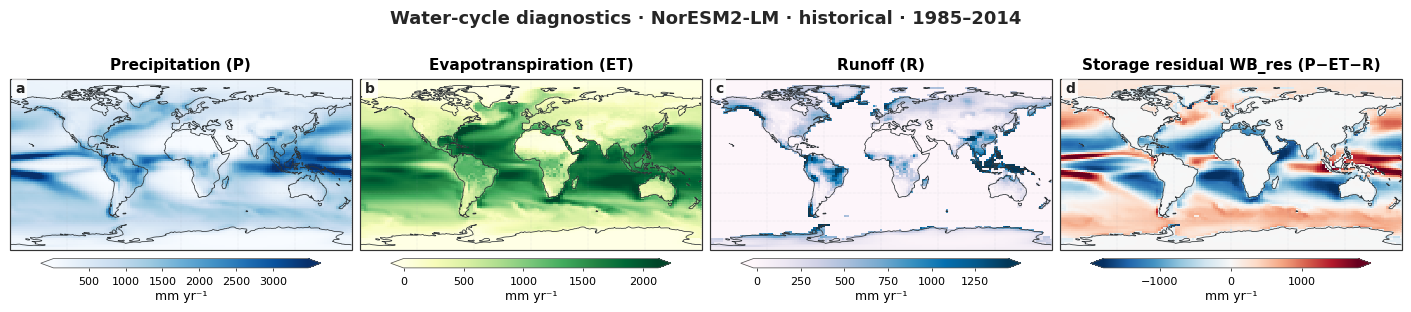

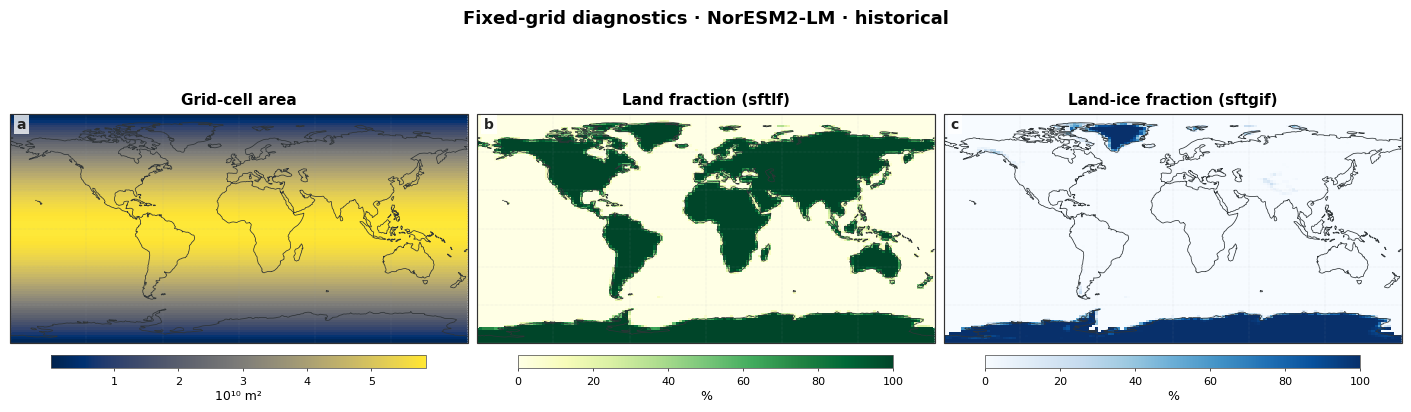

NorESM2-LM: 13 time variables in climatology
       model   variable  finite_cells  missing_cells       minimum        median      maximum  negative_cells
       CESM2          P         55296              0  1.155095e+01  7.337444e+02  7230.549613               0
       CESM2         ET         55296              0 -1.627463e+01  6.271794e+02  3618.191723            3593
       CESM2          R         21013          34283 -2.203702e+03  9.937237e+01  6060.101537            3141
       CESM2        tas         55296              0  2.207390e+02  2.829795e+02   305.088449               0
       CESM2       rsds         55296              0  4.786528e+01  1.478850e+02   307.142791               0
       CESM2       rsus         55296              0  3.318313e+00  1.430284e+01   141.966470               0
       CESM2       rlds         55296              0  7.825708e+01  3.209206e+02   439.860061               0
       CESM2       rlus         55296              0  1.286811e+02  3.69171

In [12]:
FIXED_VAR_NAMES = {
    'cell_area', 'land_fraction', 'land_ice_fraction',
    'land_area', 'land_ice_area', 'non_ice_land_area',
}


def robust_limits(data: xr.DataArray, *, symmetric: bool = False) -> tuple[float, float]:
    values = np.asarray(data.values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return (-1.0, 1.0) if symmetric else (0.0, 1.0)
    if symmetric:
        limit = float(np.quantile(np.abs(values), 0.99))
        if not np.isfinite(limit) or limit == 0:
            limit = float(np.max(np.abs(values))) or 1.0
        return -limit, limit
    lower, upper = np.quantile(values, [0.01, 0.99])
    if np.isclose(lower, upper):
        lower, upper = float(np.min(values)), float(np.max(values))
    if np.isclose(lower, upper):
        upper = float(lower) + 1.0
    return float(lower), float(upper)


def add_safe_coastlines(ax) -> None:
    """Cartopy 0.23 + Shapely 2 can crash when Robinson clips rings into a GeometryCollection."""
    try:
        ax.coastlines(resolution='110m', linewidth=0.55, color='#2F3437')
    except Exception as exc:
        print(f'coastlines skipped: {type(exc).__name__}: {exc}')


def save_qc_figure(fig, path: Path) -> None:
    """Save the QC figure even if IPython/cartopy cannot display it."""
    try:
        fig.savefig(path, dpi=180, bbox_inches='tight')
    except TypeError as exc:
        print(f'{path.name}: cartopy/shapely draw failed ({exc}); saved without coastlines')
        for ax in fig.axes:
            for artist in list(getattr(ax, 'artists', [])) + list(ax.get_children()):
                name = type(artist).__name__
                if 'Feature' in name or 'coast' in name.lower():
                    try:
                        artist.remove()
                    except Exception:
                        pass
        try:
            fig.savefig(path, dpi=180, bbox_inches='tight')
        except TypeError as exc2:
            print(f'{path.name}: savefig still failed ({exc2}); skip map')
            return
    try:
        plt.show()
    except TypeError as exc:
        print(f'{path.name}: notebook display failed ({exc}); file is on disk')


def draw_global_panel(
    ax, data: xr.DataArray, *, title: str, cmap: str, unit: str,
    vmin: float, vmax: float, panel_label: str, extend: str = 'neither',
):
    mesh = ax.pcolormesh(
        data['lon'], data['lat'], data,
        transform=ccrs.PlateCarree(), shading='auto', rasterized=True,
        cmap=cmap, vmin=vmin, vmax=vmax,
    )
    ax.set_global()
    ax.set_facecolor('#F7FAFC')
    add_safe_coastlines(ax)
    try:
        ax.gridlines(linewidth=0.35, color='#9CA3AF', alpha=0.45, linestyle=':')
    except Exception:
        pass
    ax.spines['geo'].set_edgecolor('#333333')
    ax.spines['geo'].set_linewidth(0.85)
    ax.set_title(title, pad=7, fontsize=11, fontweight='semibold')
    ax.text(
        0.015, 0.985, panel_label, transform=ax.transAxes,
        va='top', ha='left', fontsize=10, fontweight='bold', color='#222222',
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.78, 'pad': 2},
    )
    colorbar = ax.figure.colorbar(
        mesh, ax=ax, orientation='horizontal', shrink=0.82, pad=0.035,
        aspect=30, extend=extend,
    )
    colorbar.set_label(unit, fontsize=9, labelpad=2)
    colorbar.outline.set_edgecolor('#555555')
    colorbar.outline.set_linewidth(0.55)
    colorbar.ax.tick_params(labelsize=8, length=2.5, width=0.5)
    if not bool(np.isfinite(data).any()):
        ax.text(
            0.5, 0.5, 'Unavailable', transform=ax.transAxes,
            ha='center', va='center', fontsize=11, color='#374151',
            bbox={'facecolor': 'white', 'edgecolor': '#9CA3AF', 'alpha': 0.9},
        )


# PlateCarree avoids cartopy 0.23 + shapely 2 GeometryCollection crash on Robinson clips.
projection = ccrs.PlateCarree()
qc_rows = []
summary_rows = []
qc_targets = PROCESSED if 'PROCESSED' in globals() else []

for run in qc_targets:
    model = run['model']
    processed_dir = run['run_root'] / 'processed'
    qc_dir = run['run_root'] / 'qc'
    qc_dir.mkdir(parents=True, exist_ok=True)
    period = f'{START_YEAR}–{END_YEAR}'
    clim_path = processed_dir / f'global_climatology_{START_YEAR}_{END_YEAR}.nc'
    ann_path = processed_dir / f'global_annual_{START_YEAR}_{END_YEAR}.nc'
    if not clim_path.exists() or not ann_path.exists():
        print(f'{model}: processed files missing, skip QC')
        continue

    climatology = xr.open_dataset(clim_path).load()
    annual = xr.open_dataset(ann_path).load()

    model_qc_rows = []
    for name in climatology.data_vars:
        if name in FIXED_VAR_NAMES or name == 'WB':
            continue
        values = climatology[name]
        model_qc_rows.append({
            'model': model, 'variable': name,
            'finite_cells': int(np.isfinite(values).sum()),
            'missing_cells': int(values.isnull().sum()),
            'minimum': float(values.min(skipna=True)),
            'median': float(values.median(skipna=True)),
            'maximum': float(values.max(skipna=True)),
            'negative_cells': int((values < 0).sum()),
        })
    if 'WB' in climatology:
        values = climatology['WB']
        model_qc_rows.append({
            'model': model, 'variable': 'WB',
            'finite_cells': int(np.isfinite(values).sum()),
            'missing_cells': int(values.isnull().sum()),
            'minimum': float(values.min(skipna=True)),
            'median': float(values.median(skipna=True)),
            'maximum': float(values.max(skipna=True)),
            'negative_cells': int((values < 0).sum()),
        })
    if 'ET' in annual:
        print(
            f"{model} negative ET: "
            f"annual values={int((annual['ET'] < 0).sum())}, "
            f"climatological cells={int((climatology['ET'] < 0).sum())}"
        )
    qc_rows.extend(model_qc_rows)
    pd.DataFrame(model_qc_rows).to_csv(qc_dir / 'climatology_qc.csv', index=False)
    del annual

    ds = climatology
    nlat = len(ds['lat'])
    nlon = len(ds['lon'])
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlat = abs(float(np.median(np.diff(lat_vals)))) if nlat > 1 else float('nan')
    dlon = abs(float(np.median(np.diff(lon_vals)))) if nlon > 1 else float('nan')
    time_vars = sorted(v for v in ds.data_vars if v not in FIXED_VAR_NAMES and v != 'WB')
    summary_rows.append({
        'model': run['model'],
        'family': run['family'],
        'pool': run['pool'],
        'member': run['member_id'],
        'grid_label': run['grid_label'],
        'nlat': nlat,
        'nlon': nlon,
        'dlat_deg': round(dlat, 3),
        'dlon_deg': round(dlon, 3),
        'resolution_approx': f'~{round((dlat + dlon) / 2, 1)}°',
        'n_time_vars': len(time_vars),
        'variables': ', '.join(time_vars),
        'has_ET': 'ET' in ds,
        'has_WB': 'WB' in ds,
        'land_ice_status': ds.attrs.get('land_ice_status', 'unknown'),
        'processed_status': run.get('processed_status', ''),
        'output_dir': str(run['run_root']),
    })

    try:
        water_specs = []
        if 'P' in ds:
            water_specs.append(('P', 'Precipitation (P)', 'Blues', 'mm yr⁻¹', False))
        if 'ET' in ds:
            water_specs.append(('ET', 'Evapotranspiration (ET)', 'YlGn', 'mm yr⁻¹', False))
        if 'R' in ds:
            water_specs.append(('R', 'Runoff (R)', 'PuBu', 'mm yr⁻¹', False))
        if 'WB' in ds:
            water_specs.append(('WB', 'Storage residual WB_res (P−ET−R)', 'RdBu_r', 'mm yr⁻¹', True))

        if water_specs:
            fig, axes = plt.subplots(
                1, len(water_specs), figsize=(3.5 * len(water_specs), 3),
                subplot_kw={'projection': projection}, constrained_layout=True,
            )
            if len(water_specs) == 1:
                axes = [axes]
            for panel, (ax, (name, title, cmap, unit, symmetric)) in enumerate(zip(axes, water_specs)):
                vmin, vmax = robust_limits(ds[name], symmetric=symmetric)
                draw_global_panel(
                    ax, ds[name], title=title, cmap=cmap, unit=unit,
                    vmin=vmin, vmax=vmax, panel_label=chr(97 + panel), extend='both',
                )
            fig.suptitle(
                f'Water-cycle diagnostics · {model} · {EXPERIMENT_ID} · {period}',
                fontsize=13, fontweight='semibold', color='#262626',
            )
            save_qc_figure(fig, qc_dir / 'global_climatology_maps.png')

        fixed_specs = [
            (ds['cell_area'] / 1e10, 'Grid-cell area', 'cividis', '10¹⁰ m²', None),
            (ds['land_fraction'], 'Land fraction (sftlf)', 'YlGn', '%', (0.0, 100.0)),
            (ds['land_ice_fraction'], 'Land-ice fraction (sftgif)', 'Blues', '%', (0.0, 100.0)),
        ]
        fig, axes = plt.subplots(
            1, 3, figsize=(14, 4), subplot_kw={'projection': projection}, constrained_layout=True,
        )
        for panel, (ax, (data, title, cmap, unit, limits)) in enumerate(zip(np.atleast_1d(axes).ravel(), fixed_specs)):
            vmin, vmax = limits if limits is not None else robust_limits(data)
            draw_global_panel(
                ax, data, title=title, cmap=cmap, unit=unit,
                vmin=vmin, vmax=vmax, panel_label=chr(97 + panel),
            )
        fig.suptitle(f'Fixed-grid diagnostics · {model} · {EXPERIMENT_ID}', fontsize=13, fontweight='semibold')
        save_qc_figure(fig, qc_dir / 'global_fixed_fields.png')
    except TypeError as exc:
        print(f'{model}: QC maps skipped after cartopy/shapely error: {exc}')
    except Exception as exc:
        print(f'{model}: QC maps skipped: {type(exc).__name__}: {exc}')

    print(f'{model}: {len(time_vars)} time variables in climatology')
    del ds, climatology
    plt.close('all')
    gc.collect()

QC = pd.DataFrame(qc_rows)
print(QC.to_string(index=False) if not QC.empty else 'No QC rows')
if not QC.empty:
    QC = _merge_and_save(QC, DATA_ROOT / 'global_climatology_qc_summary.csv', ['model', 'variable'])
    print(f'QC summary: {QC["model"].nunique()} models total')

SUMMARY = pd.DataFrame(summary_rows)
if not SUMMARY.empty:
    SUMMARY = _merge_and_save(SUMMARY, DATA_ROOT / 'S1_processed_summary.csv', ['model'])
    print(f'Processed summary: {SUMMARY["model"].nunique()} models total')
print(SUMMARY.to_string(index=False) if not SUMMARY.empty else 'No summary')


## 5. Handoff / 后续交接

Products: `/Volumes/mimi-T9/CMIP6/{model}/historical/{member}/{grid}/processed/`.

S2 should read these files. Re-run this notebook after more S1 downloads finish; unchanged signatures are skipped.

**中文说明：** 先`PROCESS_MODELS = ['CanESM5']`，再改`None`。S1继续只下载。
